Câu 1 (5 điểm): Cho đồ thị vô hướng G = (V,E) như hình vẽ với V là tập đỉnh và E là tập cạnh.
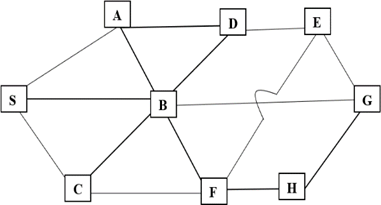

a)	(2 điểm) Hãy viết đoạn code biểu diễn đồ thị trên bằng cách khởi tạo tập đỉnh V và tập cạnh E. (Ví dụ: V = [“S”, “A”, “B”], E =[(“S”, “A”), (“S”, “B”)])

Dán code:

In [4]:
V = ["S", "A", "B", "C", "D", "E", "F", "G", "H"]

E = [
    ("S", "A"),
    ("S", "B"),
    ("S", "C"),
    ("A", "B"),
    ("A", "D"),
    ("B", "C"),
    ("B", "D"),
    ("B", "F"),
    ("B", "G"),
    ("C", "F"),
    ("D", "E"),
    ("E", "F"),
    ("E", "G"),
    ("F", "H"),
    ("G", "H"),
]

class Graph:
    def __init__(self):
        self.adjacency = {}

    def add_node(self, node):
        if node not in self.adjacency:
            self.adjacency[node] = []

    def add_edge(self, u, v):
        self.add_node(u)
        self.add_node(v)
        self.adjacency[u].append(v)
        self.adjacency[v].append(u)


def build_graph(vertices, edges):
    graph = Graph()

    for vertex in vertices:
        graph.add_node(vertex)

    for u, v in edges:
        graph.add_edge(u, v)

    return graph


def main():
    graph = build_graph(V, E)

    print("Tap dinh V:")
    print(V)
    print()
    print("Tap canh E:")
    print(E)
    print()
    print("Danh sach ke:")

    for vertex in V:
        neighbors = ", ".join(graph.adjacency[vertex])
        print(f"{vertex}: {neighbors}")


if __name__ == "__main__":
    main()

Tap dinh V:
['S', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Tap canh E:
[('S', 'A'), ('S', 'B'), ('S', 'C'), ('A', 'B'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('B', 'F'), ('B', 'G'), ('C', 'F'), ('D', 'E'), ('E', 'F'), ('E', 'G'), ('F', 'H'), ('G', 'H')]

Danh sach ke:
S: A, B, C
A: S, B, D
B: S, A, C, D, F, G
C: S, B, F
D: A, B, E
E: D, F, G
F: B, C, E, H
G: B, E, H
H: F, G


### Giải thích câu a

Ở câu a, mục tiêu của em là biểu diễn đồ thị vô hướng theo đúng dạng toán học của nó, tức là dưới dạng $G = (V, E)$.

- `V` là tập đỉnh của đồ thị, tức là toàn bộ các nút xuất hiện trong hình.
- `E` là tập cạnh, tức là các cặp đỉnh có nối với nhau bằng một cạnh trong đồ thị.

Vì đây là đồ thị vô hướng nên mỗi cạnh chỉ cần ghi một lần trong tập `E`, nhưng khi đưa vào cấu trúc dữ liệu của chương trình thì cạnh đó sẽ được hiểu theo cả hai chiều. Nói cách khác, nếu có cạnh giữa hai đỉnh thì từ đỉnh này có thể đi sang đỉnh kia và ngược lại.

Trong phần cài đặt, em chọn cách lưu đồ thị bằng danh sách kề. Cách lưu này phù hợp vì:

- dễ kiểm tra các đỉnh kề với một đỉnh bất kỳ,
- thuận lợi cho các thuật toán tìm kiếm như DFS ở câu b,
- bám sát được cấu trúc của đồ thị trong hình vẽ.

Quy trình em làm ở câu a gồm các bước chính:

1. Khởi tạo tập đỉnh `V` theo đúng các đỉnh xuất hiện trên hình.
2. Khởi tạo tập cạnh `E` theo đúng các liên kết giữa các đỉnh.
3. Tạo một đối tượng đồ thị rỗng.
4. Thêm lần lượt từng đỉnh vào đồ thị.
5. Duyệt qua từng cạnh trong `E` để đưa vào danh sách kề.

Kết quả của câu a là ta thu được một biểu diễn đầy đủ của không gian trạng thái/không gian tìm kiếm của bài toán dưới dạng đồ thị. Từ đó, các câu sau có thể sử dụng trực tiếp cấu trúc này để thực hiện tìm kiếm đường đi.

### Nhận xét về kết quả câu a

Sau khi dựng xong đồ thị, ta kiểm tra lại danh sách đỉnh và danh sách cạnh để chắc chắn rằng đồ thị đã được mô tả đúng như hình.

Danh sách kề là phần quan trọng nhất của biểu diễn này vì nó cho biết từ mỗi đỉnh có thể đi đến những đỉnh nào. Đây chính là dữ liệu mà thuật toán DFS sẽ dùng ở câu b để mở rộng trạng thái theo chiều sâu.

Nếu danh sách kề khớp với hình vẽ thì có thể xem phần biểu diễn đồ thị ở câu a là hoàn thành chính xác.

b)	(3 điểm) Hãy viết chương trình sử dụng thuật toán tìm kiếm theo chiều sâu (DFS) để tìm đường đi từ đỉnh “S” đến đỉnh “G” trong đồ thị được biểu diễn ở câu a). Trong chương trình, hãy in ra thứ tự đỉnh khám phá trong quá trình tìm kiếm. Nếu không tìm thấy thì in “Khong tim thay duong di”

Dán code:

In [6]:
V = ["S", "A", "B", "C", "D", "E", "F", "G", "H"]

E = [
    ("S", "A"),
    ("S", "B"),
    ("S", "C"),
    ("A", "B"),
    ("A", "D"),
    ("B", "C"),
    ("B", "D"),
    ("B", "F"),
    ("B", "G"),
    ("C", "F"),
    ("D", "E"),
    ("E", "F"),
    ("E", "G"),
    ("F", "H"),
    ("G", "H"),
]

class Graph:
    def __init__(self):
        self.adjacency = {}

    def add_node(self, node):
        if node not in self.adjacency:
            self.adjacency[node] = []

    def add_edge(self, u, v):
        self.add_node(u)
        self.add_node(v)
        self.adjacency[u].append(v)
        self.adjacency[v].append(u)

    def sort_neighbors(self, vertex_order):
        for vertex in self.adjacency:
            self.adjacency[vertex].sort(key=lambda item: vertex_order[item])


def build_graph(vertices, edges):
    graph = Graph()

    for vertex in vertices:
        graph.add_node(vertex)

    for u, v in edges:
        graph.add_edge(u, v)

    vertex_order = {vertex: index for index, vertex in enumerate(vertices)}
    graph.sort_neighbors(vertex_order)
    return graph


def reconstruct_path(parent, start, goal):
    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = parent[current]

    path.reverse()
    return path if path[0] == start else None


def format_parent_map(parent):
    items = []

    for vertex, previous in parent.items():
        previous_text = "None" if previous is None else previous
        items.append(f"{vertex}:{previous_text}")

    return "{" + ", ".join(items) + "}"


def format_dfs_steps(steps):
    if not steps:
        return "Khong co buoc DFS nao duoc ghi nhan."

    headers = ["Step", "Popped", "Stack", "Discovered", "Parents"]
    rows = []

    for step_index, popped, stack_snapshot, discovered_nodes, parent_snapshot in steps:
        stack_text = "[" + ", ".join(stack_snapshot) + "]"
        discovered_text = ", ".join(discovered_nodes) if discovered_nodes else "-"
        parent_text = format_parent_map(parent_snapshot)
        rows.append([
            str(step_index),
            popped,
            stack_text,
            discovered_text,
            parent_text,
        ])

    widths = [len(header) for header in headers]

    for row in rows:
        for index, value in enumerate(row):
            widths[index] = max(widths[index], len(value))

    def pad(value, width):
        return value.ljust(width)

    lines = []
    lines.append(" | ".join(pad(header, widths[index]) for index, header in enumerate(headers)))
    lines.append("-+-".join("-" * width for width in widths))

    for row in rows:
        lines.append(" | ".join(pad(value, widths[index]) for index, value in enumerate(row)))

    return "\n".join(lines)


def dfs(adjacency, start, goal):
    stack = [start]
    visited = set()
    discovered = {start}
    parent = {start: None}
    exploration_order = []
    steps = []
    step_index = 0

    while stack:
        step_index += 1
        current = stack.pop()

        if current in visited:
            steps.append((step_index, current, list(stack), [], dict(parent)))
            continue

        visited.add(current)
        exploration_order.append(current)
        discovered_this_step = []

        if current == goal:
            steps.append((step_index, current, list(stack), discovered_this_step, dict(parent)))
            return reconstruct_path(parent, start, goal), exploration_order, steps

        for neighbor in reversed(adjacency[current]):
            if neighbor not in discovered:
                discovered.add(neighbor)
                parent[neighbor] = current
                stack.append(neighbor)
                discovered_this_step.append(neighbor)

        steps.append((step_index, current, list(stack), discovered_this_step, dict(parent)))

    return None, exploration_order, steps


def format_adjacency(adjacency):
    lines = []

    for vertex in V:
        neighbors = ", ".join(adjacency[vertex])
        lines.append(f"{vertex}: {neighbors}")

    return "\n".join(lines)


def main():
    graph = build_graph(V, E)
    path, exploration_order, steps = dfs(graph.adjacency, "S", "G")

    print("Tap dinh V:")
    print(V)
    print()
    print("Tap canh E:")
    print(E)
    print()
    print("Danh sach ke:")
    print(format_adjacency(graph.adjacency))
    print()
    print("Bang cac buoc DFS:")
    print(format_dfs_steps(steps))
    print()
    print("Thu tu dinh kham pha:")
    print(" -> ".join(exploration_order))
    print()

    if path is None:
        print("Khong tim thay duong di")
    else:
        print("Duong di tu S den G:")
        print(" -> ".join(path))


if __name__ == "__main__":
    main()

Tap dinh V:
['S', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Tap canh E:
[('S', 'A'), ('S', 'B'), ('S', 'C'), ('A', 'B'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('B', 'F'), ('B', 'G'), ('C', 'F'), ('D', 'E'), ('E', 'F'), ('E', 'G'), ('F', 'H'), ('G', 'H')]

Danh sach ke:
S: A, B, C
A: S, B, D
B: S, A, C, D, F, G
C: S, B, F
D: A, B, E
E: D, F, G
F: B, C, E, H
G: B, E, H
H: F, G

Bang cac buoc DFS:
Step | Popped | Stack        | Discovered | Parents                                         
-----+--------+--------------+------------+-------------------------------------------------
1    | S      | [C, B, A]    | C, B, A    | {S:None, C:S, B:S, A:S}                         
2    | A      | [C, B, D]    | D          | {S:None, C:S, B:S, A:S, D:A}                    
3    | D      | [C, B, E]    | E          | {S:None, C:S, B:S, A:S, D:A, E:D}               
4    | E      | [C, B, G, F] | G, F       | {S:None, C:S, B:S, A:S, D:A, E:D, G:E, F:E}     
5    | F      | [C, B, G, H] | H          | {S:

### Giải thích tác dụng của từng hàm

- `Graph.__init__()`: khởi tạo đồ thị rỗng bằng biến `adjacency`, trong đó mỗi đỉnh tương ứng với một danh sách các đỉnh kề.
- `Graph.add_node(node)`: thêm một đỉnh vào đồ thị nếu đỉnh đó chưa có trong `adjacency`.
- `Graph.add_edge(u, v)`: thêm cạnh vô hướng giữa hai đỉnh `u` và `v`, nên cả hai đỉnh đều được thêm vào danh sách kề của nhau.
- `Graph.sort_neighbors(vertex_order)`: sắp xếp danh sách kề theo thứ tự của tập đỉnh `V`, giúp quá trình DFS cho kết quả ổn định và dễ đối chiếu.
- `build_graph(vertices, edges)`: tạo đối tượng `Graph`, thêm toàn bộ đỉnh và cạnh, sắp xếp danh sách kề rồi trả về đồ thị hoàn chỉnh.
- `reconstruct_path(parent, start, goal)`: truy vết đường đi từ `goal` ngược về `start` bằng dictionary `parent`, sau đó đảo ngược lại để lấy đường đi đúng chiều.
- `format_parent_map(parent)`: chuyển thông tin cha của các đỉnh thành chuỗi dạng `{đỉnh:cha}` để hiển thị trong bảng bước chạy.
- `format_dfs_steps(steps)`: định dạng danh sách các bước DFS thành bảng văn bản, gồm bước, đỉnh vừa lấy khỏi stack, trạng thái stack, các đỉnh mới phát hiện và quan hệ cha.
- `pad(value, width)`: hàm phụ bên trong `format_dfs_steps`, dùng để căn trái nội dung từng cột khi in bảng.
- `dfs(adjacency, start, goal)`: thực hiện thuật toán DFS bằng stack. Hàm lấy đỉnh ở cuối stack ra xử lý, đánh dấu đã thăm, mở rộng các đỉnh kề, lưu `parent`, lưu thứ tự khám phá và trả về đường đi nếu gặp `goal`.
- `format_adjacency(adjacency)`: chuyển danh sách kề của đồ thị thành chuỗi nhiều dòng để in ra dễ đọc.
- `main()`: hàm điều khiển chính, xây dựng đồ thị, gọi DFS từ `S` đến `G`, rồi in danh sách kề, bảng bước chạy, thứ tự khám phá và đường đi tìm được.

### Giải thích câu b

Ở câu b, em sử dụng thuật toán DFS để tìm đường đi từ đỉnh `S` đến đỉnh `G` trên đồ thị đã biểu diễn ở câu a.

DFS hoạt động theo nguyên tắc duyệt đi sâu trước. Nghĩa là từ đỉnh xuất phát `S`, thuật toán sẽ:

- chọn một đỉnh kề chưa thăm để đi tiếp,
- tiếp tục đi sâu theo nhánh đó,
- và quay lui để xét nhánh khác nếu nhánh hiện tại không dẫn đến đích.

Cách làm này phù hợp với bài toán tìm một đường đi trong đồ thị. DFS không đảm bảo đường đi tìm được là ngắn nhất, nhưng vẫn tìm được một đường đi hợp lệ nếu đường đi đó tồn tại.

### Công thức / nguyên tắc sử dụng

DFS không dùng hàm chi phí hay heuristic. Thuật toán dựa trên nguyên tắc vào sau ra trước của ngăn xếp:

```text
LIFO = Last In, First Out
```

Khi một đỉnh được lấy ra khỏi ngăn xếp, chương trình đánh dấu đỉnh đó đã thăm và tiếp tục đi sâu theo các đỉnh kề chưa được phát hiện.

Trong quá trình cài đặt, em sử dụng các thành phần sau:

- một ngăn xếp để lưu các đỉnh chờ được khám phá,
- một tập `visited` để tránh lặp lại đỉnh đã xét,
- một tập `discovered` để tránh đưa cùng một đỉnh vào ngăn xếp nhiều lần,
- một cấu trúc lưu đỉnh cha để truy vết lại đường đi sau khi tìm thấy đích,
- một danh sách ghi lại thứ tự các đỉnh được lấy ra khỏi ngăn xếp,
- một bảng ghi lại từng bước xử lý của DFS.

Ý nghĩa của từng phần:

1. Ngăn xếp giúp DFS luôn xử lý đỉnh theo đúng thứ tự vào sau ra trước.
2. Tập `visited` giúp chương trình không đi vòng lặp vô hạn qua các cạnh vô hướng.
3. Tập `discovered` giúp tránh thêm trùng đỉnh vào ngăn xếp trong quá trình duyệt.
4. Thông tin đỉnh cha cho phép lần ngược lại từ `G` về `S` để dựng ra đường đi hoàn chỉnh.
5. Danh sách thứ tự khám phá dùng để báo cáo quá trình tìm kiếm theo yêu cầu đề bài.
6. Bảng các bước DFS giúp theo dõi rõ sau mỗi lần lấy một đỉnh ra khỏi ngăn xếp thì chương trình đã phát hiện thêm những đỉnh nào.

Khi thuật toán lấy được một đỉnh ra khỏi ngăn xếp, em kiểm tra:

- nếu đỉnh đó là `G` thì dừng ngay và truy vết đường đi,
- nếu chưa phải `G` thì xét các đỉnh kề chưa được phát hiện, thêm chúng vào ngăn xếp và lưu lại đỉnh cha.

Trong chương trình, khi xét các đỉnh kề, em duyệt theo thứ tự ngược trước khi đưa vào ngăn xếp. Như vậy khi lấy ra khỏi ngăn xếp, thứ tự ưu tiên vẫn bám theo thứ tự của tập đỉnh `V`.

Nếu duyệt hết mà không gặp `G` thì kết luận không tồn tại đường đi và in ra đúng thông báo mà đề bài yêu cầu.

Như vậy, câu b không chỉ tìm được đường đi từ `S` đến `G`, mà còn cho thấy rõ thứ tự mở rộng các đỉnh trong quá trình DFS.


### Nhận xét về kết quả câu b

Kết quả cuối cùng cho thấy thuật toán đã tìm được một đường đi từ `S` đến `G` là `S -> A -> D -> E -> G`.

Đây là một đường đi hợp lệ trong đồ thị vì:

- từ `S` có thể đi đến `A`,
- từ `A` có thể đi đến `D`,
- từ `D` có thể đi đến `E`,
- từ `E` có thể đi đến `G`.

Thứ tự đỉnh khám phá cũng phản ánh đúng cơ chế hoạt động theo chiều sâu của DFS. Thuật toán ưu tiên đi sâu theo một nhánh trước, cụ thể là đi từ `S` sang `A`, rồi tiếp tục đến `D`, `E`, `F`, `H` trước khi gặp `G`.

Dán kết quả thực thi:

```text
Tap dinh V:
['S', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Tap canh E:
[('S', 'A'), ('S', 'B'), ('S', 'C'), ('A', 'B'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('B', 'F'), ('B', 'G'), ('C', 'F'), ('D', 'E'), ('E', 'F'), ('E', 'G'), ('F', 'H'), ('G', 'H')]

Danh sach ke:
S: A, B, C
A: S, B, D
B: S, A, C, D, F, G
C: S, B, F
D: A, B, E
E: D, F, G
F: B, C, E, H
G: B, E, H
H: F, G

Bang cac buoc DFS:
Step | Popped | Stack        | Discovered | Parents                                         
-----+--------+--------------+------------+-------------------------------------------------
1    | S      | [C, B, A]    | C, B, A    | {S:None, C:S, B:S, A:S}                         
2    | A      | [C, B, D]    | D          | {S:None, C:S, B:S, A:S, D:A}                    
3    | D      | [C, B, E]    | E          | {S:None, C:S, B:S, A:S, D:A, E:D}               
4    | E      | [C, B, G, F] | G, F       | {S:None, C:S, B:S, A:S, D:A, E:D, G:E, F:E}     
5    | F      | [C, B, G, H] | H          | {S:None, C:S, B:S, A:S, D:A, E:D, G:E, F:E, H:F}
6    | H      | [C, B, G]    | -          | {S:None, C:S, B:S, A:S, D:A, E:D, G:E, F:E, H:F}
7    | G      | [C, B]       | -          | {S:None, C:S, B:S, A:S, D:A, E:D, G:E, F:E, H:F}

Thu tu dinh kham pha:
S -> A -> D -> E -> F -> H -> G

Duong di tu S den G:
S -> A -> D -> E -> G
```